Our quantifications match the visualization -- subsetting to the test conditions of interest in a given fold

In [1]:
# import warnings

# warnings.resetwarnings()

# warnings.filterwarnings(
#     "ignore",
#     category=FutureWarning,
#     message=r".*__version__ is deprecated.*"
# )

# warnings.filterwarnings(
#     "ignore",
#     category=UserWarning,
#     message=r"Observation names are not unique.*"
# )

# warnings.filterwarnings(
#     "ignore",
#     module=r"scanpy(\..*)?$"
# )

# warnings.filterwarnings(
#     "ignore",
#     module=r"anndata(\..*)?$"
# )

# warnings.filterwarnings("ignore", module=r"scanpy(\..*)?$")
# warnings.filterwarnings("ignore", module=r"anndata(\..*)?$")
# warnings.filterwarnings("ignore", message="Observation names are not unique.*")
# warnings.filterwarnings("ignore", message="`__version__` is deprecated.*")
# warnings.filterwarnings('ignore', category=FutureWarning, module='scanpy')
# warnings.filterwarnings("ignore", category=FutureWarning)
# warnings.filterwarnings("ignore", category=DeprecationWarning)
# warnings.filterwarnings("ignore", category=ImportWarning)

# from anndata._warnings import ImplicitModificationWarning
# warnings.filterwarnings(
#     "ignore",
#     category=ImplicitModificationWarning
# )


In [ ]:
import os
import sys
import warnings
import copy
from collections import defaultdict
import itertools

from tqdm import trange

import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cosine as cosine_distance
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from Kang_utils import all_data, pca_mod

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, pb_y_pred, load_test_tfadata

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.metrics import distances

In [ ]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Kang'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

merged_adatas_rand = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_rand_predictions.pickle'.format(author))
)


mod_types = {
    'actual': merged_adatas, 
    'random': merged_adatas_rand
}


In [4]:
n_folds = 5

In [5]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)


The cosine distance metric doesn't make sense here since we have both perturbed and cotnrol cells in the test. 

The rank-based metric doesn't make sense because there are only two perturbations. 

# EMD Loss

This is the simple single-cell loss of the model prediction

Latent space this time is just fit on conditions, does not include controls.

In [6]:


# format for emd loss
pca_mods = {}
for fold in range(5):
    for test_cond in get_split(fold, author)['test_conds']:
        pca_mods[test_cond] = pca_mod

In [7]:
loss_res = defaultdict(list)

for (fold, (mod_type, merged_adatas_), latent_models) in itertools.product(range(n_folds), mod_types.items(), [None, pca_mods]):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, author, merged_adatas_, tf_adata)
    emd_loss = distances.get_EMD_loss(
        tf_adata_actual, tf_adata_predicted, 
        groupby_col = 'condition', # per test condition
        latent_models = latent_models, 
    )['Mean EMD Loss']


    loss_res['Mean EMD Loss'].append(emd_loss)
    loss_res['Space'].append('Full Feature Space' if latent_models is None else 'PCA Space')
    loss_res['Fold'].append(fold + 1)
    loss_res['mod_type'].append(mod_type)
        
loss_res = pd.DataFrame(loss_res) 
loss_res.mod_type = pd.Categorical(loss_res.mod_type, 
                                   categories = ['actual', 'random'], 
                                   ordered = True
                                  ).map({
    'actual': 'Actual', 'random': 'Random'
    
})

In [25]:
def emd_viz(
    space, 
    loss_res,
    loss_col: str = 'Mean EMD Loss', 
    fig_name = None, 
    show_fig = True
):

    viz_df = loss_res[loss_res.Space == space].copy()
    
    fig, ax = plt.subplots(figsize = (4.5, 4), constrained_layout = True)


    sns.violinplot(data = viz_df, x = 'mod_type', y = loss_col, ax = ax)
    ax.set_title(space)
#     ax.set_title('Kang Dataset', fontweight = 'bold')
    ax.set_xlabel('Model Type')

    
    # stats
    a = viz_df[viz_df.mod_type == 'Actual'][loss_col].values
    b = viz_df[viz_df.mod_type == 'Random'][loss_col].values

    pval = stats.wilcoxon(a, b, alternative = 'less').pvalue
    cd = cohens_d_paired(a,b)
    ax.text(
        0.02, 0.98,
        f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
        transform=ax.transAxes,
        ha="left", va="top", 
        fontsize=12
    )
    
    if fig_name is not None:
        dirpath  = os.path.dirname(fig_name)
        basename = os.path.basename(fig_name)
        stem, _  = os.path.splitext(basename)
        out_base = os.path.join(dirpath, stem)
        
        plt.savefig(
            "{}.png".format(out_base),
            dpi=1200,
            bbox_inches="tight",
            transparent=True,
        )

        plt.savefig(
            "{}.svg".format(out_base),
            format="svg",
            bbox_inches="tight",
        )
        
    if show_fig:
        plt.show()
    ;

In [22]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

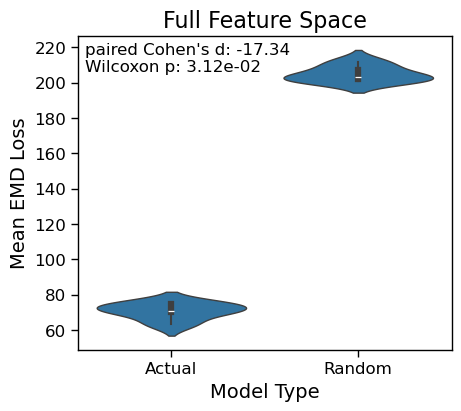

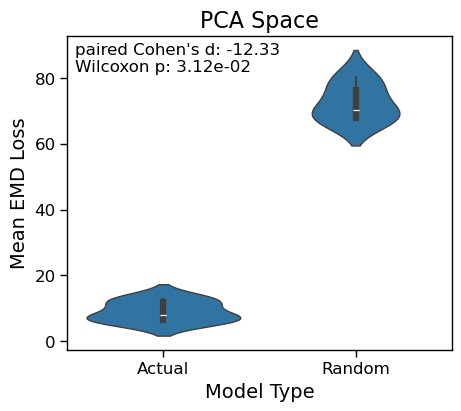

In [26]:
for space in ['Full Feature Space', 'PCA Space']:
    emd_viz(
        space, 
        loss_res,
        loss_col = 'Mean EMD Loss',
        fig_name = os.path.join(data_path, 'figures', '{}_{}_EMD_test_loss.png'.format(space.replace(' ', '_'), author)), 
        show_fig = True
    )


# Rank loss

Perturbench (https://arxiv.org/html/2408.10609v3)


Because the random baseline yields a degenerate distribution at 0.5, significance was assessed using a one-sample binomial (sign) test against chance, evaluating whether performance exceeded 0.5 across folds.

In [71]:
# pca_mods = {}
# for fold in range(5):
#     pca_mods[fold] = pca_mod

In [72]:
# loss_res = defaultdict(list)

# for (fold, (mod_type, merged_adatas_), latent_models) in itertools.product(range(n_folds), mod_types.items(), [None, pca_mods]):
#     tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, author, merged_adatas_, tf_adata)
#     if latent_models is not None:
#         latent_model = copy.deepcopy(pca_mods[fold])
#     else:
#         latent_model = None
    
#     rsa, rs = distances.rank_score(
#         tf_adata_actual, 
#         tf_adata_predicted, 
#         pert_col = pert_col,
#         distance_metric = 'manhattan', 
#         latent_model = latent_model,
#     )


#     loss_res['Mean Rank Score'].append(rsa)
#     loss_res['All Rank Scores'].append(rs)
#     loss_res['Space'].append('Full Feature Space' if latent_model is None else 'PCA Space')
#     loss_res['Fold'].append(fold + 1)
#     loss_res['mod_type'].append(mod_type)
        
# loss_res = pd.DataFrame(loss_res) 
# loss_res.mod_type = pd.Categorical(loss_res.mod_type, 
#                                    categories = ['actual', 'random'], 
#                                    ordered = True
#                                   ).map({
#     'actual': 'Actual', 'random': 'Random'
    
    
# })

In [73]:
# def rank_viz(
#     space, 
#     loss_res,
#     loss_col: str = 'Mean EMD Loss', 
#     fig_name = None, 
#     show_fig = True
# ):

#     viz_df = loss_res[loss_res.Space == space].copy()
    
#     fig, ax = plt.subplots(figsize = (4, 3), constrained_layout = True)


#     sns.violinplot(data = viz_df, x = 'mod_type', y = loss_col)
#     ax.set_title(space)
#     ax.set_xlabel('Model Type')

    
#     # stats
#     actual = viz_df[viz_df.mod_type == 'Actual'][loss_col].values
# #     b = viz_df[viz_df.mod_type == 'Random'][loss_col].values

#     n_pos = np.sum(actual > 0.5)
#     n_tot = len(actual)

#     pval = stats.binomtest(
#         n_pos,
#         n_tot,
#         p=0.5,
#         alternative="greater"
#     ).pvalue

# #     cd = cohens_d_paired(a,b)
#     ax.text(
#         0.55, 0.96, 
#         "Sign test p: {:.2E}".format(pval),
#         transform=ax.transAxes,
#         ha="left", va="top", 
#         fontsize=10
#     )
    
    
# #     ax.text(
# #         0.55, 0.98,
# #         f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
# #         transform=ax.transAxes,
# #         ha="left", va="top", 
# #         fontsize=12
# #     )
    
#     if fig_name is not None:
#         dirpath  = os.path.dirname(fig_name)
#         basename = os.path.basename(fig_name)
#         stem, _  = os.path.splitext(basename)
#         out_base = os.path.join(dirpath, stem)
        
#         plt.savefig(
#             "{}.png".format(out_base),
#             dpi=1200,
#             bbox_inches="tight",
#             transparent=True,
#         )

#         plt.savefig(
#             "{}.svg".format(out_base),
#             format="svg",
#             bbox_inches="tight",
#         )
        
#     if show_fig:
#         plt.show()
#     ;

In [75]:
# for space in ['Full Feature Space', 'Test Condition Specific PLS Space']:
#     rank_viz(
#         space, 
#         loss_res,
#         loss_col = 'Mean Rank Score',
# #         fig_name = os.path.join(data_path, 'figures', 'rank_test_loss'), 
#         show_fig = True
#     )

In [76]:
# ncols = n_folds
# nrows = 2
# fig, ax = plt.subplots(
#     ncols=ncols,
#     nrows=nrows,
#     figsize=(5.1*ncols, 5.1*nrows),
#     constrained_layout=True
# )
# fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)

# row_spaces = [
#     "Full Feature Space",
#     "Test Condition Specific PLS Space"
# ]

# for i, space in enumerate(row_spaces):

#     # ---- IMPORTANT: filter per row ----
#     viz_df = loss_res[loss_res.Space == space].copy()

#     for j in range(ncols):
#         fold = j + 1
#         viz_df_fold = viz_df[viz_df.Fold == fold].copy()
#         # --- reshape to one row per (Perturbation, mod_type) ---
#         viz_df_fold = (
#             viz_df_fold
#             .drop(columns=["Mean Rank Score"])
#             .assign(**{
#                 "All Rank Scores": viz_df_fold["All Rank Scores"].apply(dict.items)
#             })
#             .explode("All Rank Scores")
#             .assign(
#                 Perturbation=lambda x: x["All Rank Scores"].apply(lambda kv: kv[0]),
#                 Rank_Score=lambda x: x["All Rank Scores"].apply(lambda kv: kv[1]),
#             )
#             .drop(columns=["All Rank Scores"])
#         )

#         # Ensure order: Actual then Random
#         viz_df_fold["mod_type"] = pd.Categorical(
#             viz_df_fold["mod_type"],
#             categories=["Actual", "Random"],
#             ordered=True
#         )

#         # Order perturbations consistently (keep appearance stable)
#         pert_order = list(pd.unique(viz_df_fold["Perturbation"]))
#         viz_df_fold["Perturbation"] = pd.Categorical(
#             viz_df_fold["Perturbation"],
#             categories=pert_order,
#             ordered=True
#         )

#         # --- build numeric x positions with small offsets for mod_type ---
#         x_base = {p: k for k, p in enumerate(pert_order)}  # 0..K-1
#         offset = {"Actual": -0.12, "Random": +0.12}        # close together

#         viz_df_fold["xpos"] = viz_df_fold.apply(
#             lambda r: x_base[r["Perturbation"]] + offset[r["mod_type"]],
#             axis=1
#         )

#         # --- lollipop stems (behind points) ---
#         for x, y in zip(viz_df_fold["xpos"], viz_df_fold["Rank_Score"]):
#             ax[i, j].vlines(
#                 x, ymin=0, ymax=y,
#                 linestyle="dashed",
#                 color="gray",
#                 zorder=1
#             )

#         # --- points (colored by mod_type) ---
#         sns.scatterplot(
#             data=viz_df_fold,
#             x="xpos",
#             y="Rank_Score",
#             hue="mod_type",
#             hue_order=["Actual", "Random"],
#             ax=ax[i, j],
#             s=60,                # adjust marker size as you like
#             edgecolor="none",
#             zorder=2
#         )

#         # --- reference lines ---
#         ax[i, j].axhline(y=0, color="black", zorder = 0)
        
#         mean_actual = viz_df_fold[viz_df_fold.mod_type == 'Actual'].Rank_Score.mean()
#         mean_rand = viz_df_fold[viz_df_fold.mod_type == 'Random'].Rank_Score.mean()
        
#         ax[i, j].axhline(
#             y=mean_actual,
#             color=sns.color_palette('Set1')[1],
#             linestyle="--",
#             label="scLEMBAS Mean Rank Score", zorder = 0
#         )
        
#         ax[i, j].axhline(
#             y=mean_rand,
#             color=sns.color_palette('Set1')[4],
#             linestyle="--",
#             label="Random Baseline Mean Rank Score", zorder = 0
#         )
        
#         ax[i, j].axhline(
#             y=0.5,
#             color="red",
#             linestyle="--",
#             label="Theoretical Random Rank Score", zorder = 0
#         )


#         # --- x ticks: ONLY perturbations (centered between the two dots) ---
#         ax[i, j].set_xticks(list(x_base.values()))
#         ax[i, j].set_xticklabels(pert_order, rotation=45, ha="right")

#         # make room for side-by-side points + keep groups separated
#         ax[i, j].set_xlim(-0.5, len(pert_order) - 0.5)

#         # axis labels
#         ax[i, j].set_xlabel("Perturbation")
#         ax[i, j].set_ylabel("Rank Score")

#         # legend: keep mod_type colors, and optionally keep the 0.5 line label too
#         handles, labels = ax[i, j].get_legend_handles_labels()
#         # seaborn creates a legend with a "mod_type" title + entries; we keep it
#         ax[i, j].legend(title="mod_type", frameon=False)

#         ax[i, j].set_title(f"Fold {fold}")
#         ax[i, j].set_xlabel("Included Model Components")

#         if (i, j) == (0, 0):
#             ax[i, j].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
#         else:
#             leg = ax[i, j].get_legend()
#             if leg is not None:
#                 leg.remove()
#         if j != 0:
#             ax[i,j].set_ylabel('')
#         if i != 1:
#             ax[i,j].set_xlabel('')
#         if i != 0:
#             ax[i,j].set_title('')

# # ---- shared legend (unchanged) ----
# leg = ax[0, 0].get_legend()
# handles = leg.legend_handles
# labels = [t.get_text() for t in leg.get_texts()]

# fig.legend(
#     handles,
#     labels,
#     loc="upper center",
#     ncol=2,
#     bbox_to_anchor=(0.3, 1.075)
# )
# ax[0, 0].legend_.remove()

# # ---- row-level "suptitles" ----
# fig.text(0.5, 1.025, row_spaces[0], ha="center", va="top", fontsize=20, fontweight="bold")
# fig.text(0.5, 0.505,  row_spaces[1], ha="center", va="top", fontsize=20, fontweight="bold")
# ;